In [1]:
# === Core Python ===
import os
import collections
from datetime import datetime
import datetime as dt
import json 
import glob 
import string 

# === Numerical and Data Handling ===
import numpy as np
import numpy.ma as ma
import pandas as pd
import xarray as xr
import xcdat as xcd
import xskillscore as xs
from scipy.stats import pearsonr
from scipy.signal import butter, filtfilt, sosfilt, lfilter
from skimage.feature import peak_local_max

# === Plotting ===
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.pylab import rcParams
from matplotlib.patches import Polygon
from matplotlib import ticker
from matplotlib.ticker import MultipleLocator
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.ticker as mticker
from matplotlib.colors import TwoSlopeNorm,BoundaryNorm

# === Mapping and Geospatial ===
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as sticker
from cartopy.mpl.ticker import LongitudeFormatter


In [2]:
import os, string, numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib import cm, colors as mcolors
from matplotlib.colors import BoundaryNorm

class E3SMZonalPlotter:
    """
    Plotting utilities for zonal-mean products produced by ZonalMeanCalculator.

    Data conventions expected in each file:
      - variables: f"{var}_zonal_obs", f"{var}_zonal_fcst"
      - coord: 'lat' (or 'latitude'/'y') and optional vertical ('plev'/'lev'/'level' in hPa or Pa)
      - optional 'season' coord.
      - NO significance fields in these files (bias can be derived on the fly).

    data_var options for plotting:
      - "bias_zonal": derived as fcst - obs (computed if not present)
      - "obs":        plots f"{var}_zonal_obs"
      - "fcst":       plots f"{var}_zonal_fcst"
      - any exact variable name existing in the file (e.g., "T_zonal_obs")
    """

    def __init__(self, metrics_path=None, out_dir=None, region=None,
                 metric="zonalmean", seasons=("DJF","MAM","JJA","SON","ANN")):
        self.ds = None
        self.metrics_path = None
        self.out_dir = out_dir
        self.region = region
        self.metric = metric  # default to "zonalmean"
        self.seasons = list(seasons)
        if metrics_path:
            if not os.path.isfile(metrics_path):
                raise FileNotFoundError(f"Metrics file not found: {metrics_path}")
            self.ds = xr.open_dataset(metrics_path)
            self.metrics_path = metrics_path

    # ----------------- core: dataset + field resolution -----------------
    @staticmethod
    def _load_dataset(file_or_ds):
        if isinstance(file_or_ds, xr.Dataset):
            return file_or_ds
        if isinstance(file_or_ds, str):
            if not os.path.isfile(file_or_ds):
                raise FileNotFoundError(f"File not found: {file_or_ds}")
            return xr.open_dataset(file_or_ds)
        raise TypeError("Input must be a file path or xarray.Dataset")

    @staticmethod
    def _attach_bias_if_needed(ds, var):
        """If f'{var}_zonal_fcst' and f'{var}_zonal_obs' exist but 'bias_zonal' doesn't, add it."""
        fc = f"{var}_zonal_fcst"
        ob = f"{var}_zonal_obs"
        if fc in ds and ob in ds and "bias_zonal" not in ds:
            b = (ds[fc] - ds[ob]).rename("bias_zonal")
            # carry units from fcst if present
            u = ds[fc].attrs.get("units", "") or ds[ob].attrs.get("units", "")
            if u: b.attrs["units"] = u
            ds = ds.copy()
            ds["bias_zonal"] = b
        return ds

    @staticmethod
    def _map_data_var_name(ds, var, data_var):
        """Map user-friendly data_var to actual var name in ds."""
        if data_var == "obs":
            name = f"{var}_zonal_obs"
            if name in ds: return name
        if data_var == "fcst":
            name = f"{var}_zonal_fcst"
            if name in ds: return name
        # "bias_zonal" is computed/attached by _attach_bias_if_needed
        if data_var in ds:
            return data_var
        # if user passed the exact stored name like "T_zonal_obs"
        if data_var.endswith("_zonal_obs") or data_var.endswith("_zonal_fcst"):
            if data_var in ds: return data_var
        raise KeyError(f"Requested data_var='{data_var}' not found in dataset and cannot be derived.")

    # ----------------- small helpers kept from your class -----------------
    def _levels_symmetric_with_white(self, clim, *, color_bins_per_side=10, n_white_bins=2):
        vmin, vmax = float(clim[0]), float(clim[1])
        N = 2*color_bins_per_side + n_white_bins
        return np.linspace(vmin, vmax, N+1)

    def _discrete_cmap_with_white_center(self, levels, base_cmap="RdBu_r", n_white_bins=2):
        N = len(levels) - 1
        base = cm.get_cmap(base_cmap, N + 2)
        full = base(np.arange(N + 2))

        bin_colors = full[1:-1].copy()
        k = int(np.searchsorted(levels, 0.0))
        half = n_white_bins // 2
        start = max(0, k - half - (0 if n_white_bins % 2 == 0 else 1))
        stop  = min(N, k + half)
        if start == stop and 0 < k < N:
            start, stop = k-1, k
        if 0 <= start < stop <= N:
            bin_colors[start:stop] = np.array([1,1,1,1])

        listed = mcolors.ListedColormap(bin_colors, name=f"{base_cmap}_bins").with_extremes(
            under=full[0], over=full[-1]
        )
        norm = BoundaryNorm(levels, listed.N, clip=False)
        return listed, norm
        
    def _get_discrete_cmap(self, cmap_name, levels, white_center=False, extend="neither"):
        """
        Build a discrete ListedColormap and BoundaryNorm with optional darker boundary colors.
        
        Parameters
        ----------
        cmap_name : str
            Name of the base continuous colormap (e.g., "RdBu_r", "YlGnBu").
        levels : list or ndarray
            Boundaries for color intervals.
        white_center : bool, optional
            If True, set the center bin (near zero) to pure white.
        extend : str, optional
            One of {"neither", "min", "max", "both"} to control boundary extensions.
        
        Returns
        -------
        listed_cmap : ListedColormap
        norm : BoundaryNorm
        """
        base = matplotlib.colormaps.get_cmap(cmap_name)
        n_colors = len(levels) - 1
        colors = base(np.linspace(0, 1, n_colors))
    
        # Optionally make the middle bin white
        if white_center:
            mid = n_colors // 2
            colors[mid] = [1, 1, 1, 1]
    
        # === Handle extended colors ===
        if extend in ("min", "both"):
            # Darker version of first color
            dark_low = np.clip(colors[0] * 0.6, 0, 1)
            colors = np.vstack([dark_low, colors])
        if extend in ("max", "both"):
            # Darker version of last color
            dark_high = np.clip(colors[-1] * 0.6, 0, 1)
            colors = np.vstack([colors, dark_high])
    
        listed_cmap = mcolors.ListedColormap(colors)
        norm = BoundaryNorm(levels, listed_cmap.N, extend=extend)
        return listed_cmap, norm
        

    def _has_season_coord(self, ds, varname):
        return (varname in ds) and ("season" in ds[varname].coords)

    def _available_seasons(self, ds, varname):
        if self._has_season_coord(ds, varname):
            vals = list(map(str, ds[varname].coords["season"].values.tolist()))
            return vals
        return []

    @staticmethod
    def _lat_name(ds):
        for cand in ("lat", "latitude", "y"):
            if cand in ds.coords or cand in ds.dims:
                return cand
        for v in ds.data_vars:
            for cand in ("lat","latitude","y"):
                if cand in ds[v].dims:
                    return cand
        raise ValueError("Latitude coordinate not found.")

    @staticmethod
    def _vert_name(ds):
        for cand in ("plev","lev","level"):
            if cand in ds.coords or cand in ds.dims:
                return cand
        for v in ds.data_vars:
            for cand in ("plev","lev","level"):
                if cand in ds[v].dims:
                    return cand
        # vertical might be absent if fields are only lat-season
        return None

    @staticmethod
    def _to_hpa(da, vert):
        if vert is None:
            return da, False
        lev = da[vert]
        vals = np.asarray(lev.values)
        if np.size(vals) and np.nanmax(vals) > 2000:  # likely Pa
            lev_hpa = (lev/100.0).assign_attrs({**lev.attrs, "units": "hPa"})
            da = da.assign_coords({vert: lev_hpa})
            return da, True
        return da, ("hPa" in lev.attrs.get("units",""))

    @staticmethod
    def _unit_from_attrs(ds, var, field, *, data_var_request):
        # Prefer the plotted field's units
        u = ""
        if field in ds and hasattr(ds[field], "attrs"):
            u = ds[field].attrs.get("units", "") or ""
        if not u and data_var_request == "bias_zonal":
            # inherit from fcst/obs if bias had no explicit units
            for cand in (f"{var}_zonal_fcst", f"{var}_zonal_obs"):
                if cand in ds:
                    u = ds[cand].attrs.get("units", "") or u
        if u:
            return u
        # fallbacks by variable family
        if var in ("T","TREFHT","TS"): return "°C"
        if var in ("U","V"):           return "m s$^{-1}$"
        if var in ("Z","Z3"):          return "m"
        if var in ("Q",):              return "kg kg$^{-1}$"
        if var in ("PRECT",):          return "mm day$^{-1}$"
        return ""

    @staticmethod
    def _season_slice(ds, s, varname):
        da = ds[varname]
        if "season" in da.coords:
            if s in da["season"].values:
                return da.sel(season=s)
            if "ANN" in da["season"].values:
                return da.sel(season="ANN")
            return da.isel(season=0)
        return da

    @staticmethod
    def _select_p_window(da, vert, pmin=None, pmax=None):
        if vert is None or (pmin is None and pmax is None):
            return da
        lev = da[vert]
        mask = np.ones(lev.shape, dtype=bool)
        if pmin is not None: mask &= (lev >= pmin)
        if pmax is not None: mask &= (lev <= pmax)
        return da.sel({vert: lev.where(mask, drop=True)})

    def _suggest_clim_from(self, ds, var, seasons=None, varname="bias_zonal"):
        arrs = []
        vert = self._vert_name(ds)
        seas = seasons or (list(ds["season"].values) if (varname in ds and "season" in ds[varname].coords) else ["ANN"])
        for s in seas:
            if varname not in ds:
                continue
            da = self._season_slice(ds, s, varname=varname)
            da, _ = self._to_hpa(da, vert)
            arrs.append(np.asarray(da.values).ravel())
        if not arrs:
            return (-5, 5)
        vals = np.concatenate(arrs)
        vals = vals[np.isfinite(vals)]
        if vals.size == 0:
            return (-5, 5)
        q = np.nanpercentile(np.abs(vals), 95)
        lim = float(q) * 1.2 if np.isfinite(q) and q > 0 else 1.0
        base = {"T":5, "TS":5, "TREFHT":5, "U":2, "V":2, "Z":200, "Z3":200, "Q":2e-3, "PRECT":5}.get(var)
        if base is not None:
            lim = max(lim, base)
        return (-lim, lim)

    # ----------------- single-file contour -----------------
    def plot_zonal_contour(
        self, file_or_ds, var, exp="", period="", *,
        data_var="bias_zonal",            # "bias_zonal" | "obs" | "fcst" | exact name
        seasons=("ANN","JJA","DJF"),
        figsize=(8, 8), clim=None, cmap="RdBu_r",
        nlevels=21, pmin=None, pmax=None, dpi=150,
        labelsize=11, titlesize=12, ticklabelsize=10, grid=False,
        equator_line=False, equator_kwargs=None, n_white_bins=2
    ):
        ds0  = self._load_dataset(file_or_ds)
        ds   = self._attach_bias_if_needed(ds0, var)
        # resolve actual field name to plot
        field = self._map_data_var_name(ds, var, data_var)

        latn = self._lat_name(ds)
        vert = self._vert_name(ds)

        data_seas = self._available_seasons(ds, field)
        seas = [s for s in seasons if (not data_seas or s in data_seas)] or ["ANN"]

        if clim is None:
            clim = self._suggest_clim_from(ds, var, seasons=seas, varname=field)
        levels = np.linspace(clim[0], clim[1], nlevels)
        if data_var == "bias_zonal":
            # Diverging with white center at 0
            listed_cmap, norm = self._discrete_cmap_with_white_center(
                levels, base_cmap=cmap, n_white_bins=n_white_bins
            )
        else:
            # Regular continuous colormap, no forced white
            listed_cmap = cm.get_cmap(cmap, len(levels)-1)
            norm = BoundaryNorm(levels, listed_cmap.N)

        fig, axes = plt.subplots(len(seas), 1, figsize=figsize, dpi=dpi, sharex=True, constrained_layout=True)
        if len(seas) == 1:
            axes = [axes]

        last_im = None
        for i, s in enumerate(seas):
            ax = axes[i]
            da = self._season_slice(ds, s, varname=field)
            da, is_hpa = self._to_hpa(da, vert)
            da = self._select_p_window(da, vert, pmin=pmin, pmax=pmax)

            last_im = da.plot.contourf(
                ax=ax, x=latn, y=vert if vert else None,
                levels=levels, cmap=listed_cmap, norm=norm,
                add_colorbar=False, extend="both", add_labels=False
            )

            if (is_hpa or (vert == "plev")) and vert:
                ax.invert_yaxis()
                ylab = "Pressure level (hPa)"
            else:
                ylab = vert if vert else ""

            ax.set_title(s, fontweight="bold", fontsize=titlesize)
            ax.set_ylabel(ylab, fontsize=labelsize)

            if equator_line:
                ek = dict(color="0.4", lw=0.6, alpha=0.35, ls="--", zorder=2)
                if equator_kwargs: ek.update(equator_kwargs)
                ax.axvline(0, **ek)

            if grid:
                ax.grid(True, which="both", alpha=0.2)
            ax.tick_params(axis="both", labelsize=ticklabelsize)
            ax.set_xlabel("")

        axes[-1].set_xlabel("Latitude (deg)", fontsize=labelsize)

        unit = self._unit_from_attrs(ds, var, field, data_var_request=data_var)
        if data_var == "bias_zonal":
            cb_title = f"$\\Delta$ {var} ({unit})" if unit else f"$\\Delta$ {var}"
        else:
            cb_title = f"{var} ({unit})" if unit else f"{var}"

        cbar = fig.colorbar(last_im, ax=axes, orientation="horizontal", pad=0.10, extend="both")
        cbar.set_label(cb_title, fontsize=labelsize)
        cbar.ax.tick_params(labelsize=ticklabelsize)

        return fig, axes

    # --------- multi-model grid ---------
    def plot_multi_model_zonal_contours(
        self, *, files, labels, var,
        data_var="bias_zonal",          # "bias_zonal" | "obs" | "fcst" | exact
        seasons=("ANN","JJA","DJF"),
        cmap="RdBu_r", nlevels=21,
        pmin=None, pmax=None,
        vmin=None, vmax=None, levels=None, clim=None,
        figsize=None, fontsize=18, dpi=150,
        labelsize=11, titlesize=12, ticklabelsize=10, grid=False,
        equator_line=False, equator_kwargs=None, n_white_bins=2
    ):
        assert len(files) == len(labels), "files and labels must match length"
        n_cols = len(files)
        seas   = list(seasons)
        n_rows = len(seas)

        # shared clim if not provided
        if clim is None:
            vals = []
            for f in files:
                ds0 = self._load_dataset(f)
                ds  = self._attach_bias_if_needed(ds0, var)
                vert = self._vert_name(ds)
                field = self._map_data_var_name(ds, var, data_var)
                for s in seas:
                    da = self._season_slice(ds, s, field)
                    da, _ = self._to_hpa(da, vert)
                    da = self._select_p_window(da, vert, pmin=pmin, pmax=pmax)
                    vals.append(np.asarray(da.values).ravel())
            if vals:
                arr = np.concatenate(vals); arr = arr[np.isfinite(arr)]
                if arr.size:
                    q = np.nanpercentile(np.abs(arr), 95)
                    lim = float(q) * 1.2 if np.isfinite(q) and q > 0 else 1.0
                    base = {"T":5, "TS":5, "TREFHT":5, "U":2, "V":2, "Z":200, "Z3":200, "Q":2e-3, "PRECT":5}.get(var)
                    if base is not None: lim = max(lim, base)
                    clim = (-lim, lim)
                else:
                    clim = (-5, 5)
            else:
                clim = (-5, 5)

        if levels is None:
            if vmin is not None and vmax is not None:
                levels = np.linspace(vmin, vmax, nlevels)
            else:
                levels = np.linspace(clim[0], clim[1], nlevels)

        if figsize is None:
            figsize = (4.4 * n_cols, 3.2 * n_rows)

        if data_var == "bias_zonal":
            # Diverging with white center around 0
            listed_cmap, norm = self._discrete_cmap_with_white_center(
                levels, base_cmap=cmap, n_white_bins=n_white_bins
            )
        else:
            # Raw fields → normal continuous colormap, no white center
            listed_cmap, norm = self._get_discrete_cmap(
                cmap, levels, white_center=False, extend="both"
            )

        fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, dpi=dpi, sharex="col", sharey="row", constrained_layout=False)
        if n_rows == 1 and n_cols == 1:
            axes = np.array([[axes]])
        elif n_rows == 1:
            axes = np.array([axes])
        elif n_cols == 1:
            axes = np.array([[ax] for ax in axes])

        def row_letter(i):
            import string
            alph = string.ascii_lowercase
            s = ""
            i0 = i
            while True:
                s = alph[i0 % 26] + s
                i0 = i0 // 26 - 1
                if i0 < 0: break
            return s

        last_im = None
        for j, (f, label) in enumerate(zip(files, labels)):
            ds0  = self._load_dataset(f)
            ds   = self._attach_bias_if_needed(ds0, var)
            latn = self._lat_name(ds)
            vert = self._vert_name(ds)
            field = self._map_data_var_name(ds, var, data_var)

            for i, s in enumerate(seas):
                ax = axes[i][j]
                da = self._season_slice(ds, s, field)
                da, is_hpa = self._to_hpa(da, vert)
                da = self._select_p_window(da, vert, pmin=pmin, pmax=pmax)

                last_im = da.plot.contourf(
                    ax=ax, x=latn, y=vert if vert else None,
                    levels=levels, cmap=listed_cmap, norm=norm,
                    add_colorbar=False, extend="both", add_labels=False
                )

                if is_hpa and vert:
                    ax.invert_yaxis()
                    ylab = "Pressure level (hPa)"
                else:
                    ylab = vert if vert else ""

                if j == 0:
                    ax.set_ylabel(ylab, fontsize=fontsize*0.95)
                else:
                    ax.set_ylabel("")

                # panel titles
                row_tag = row_letter(i)
                panel_label = f"({row_tag}{j+1}) {label}"
                ax.set_title("", loc="center")
                ax.set_title(panel_label, fontweight="normal", loc="left", fontsize=fontsize)
                ax.set_title(s, fontweight="normal", loc="right", fontsize=fontsize)

                if i == n_rows - 1:
                    ax.set_xlabel("Latitude (degree)", fontsize=fontsize*0.95)
                else:
                    ax.set_xlabel("")

                if equator_line:
                    ek = dict(color="0.4", lw=0.6, alpha=0.35, ls="--", zorder=2)
                    if equator_kwargs: ek.update(equator_kwargs)
                    ax.axvline(0, **ek)

                if grid:
                    ax.grid(True, which="both", alpha=0.2)
                ax.tick_params(axis="both", labelsize=fontsize*0.95)

        fig.subplots_adjust(wspace=0.08, hspace=0.25, right=0.88)
        unit = self._unit_from_attrs(self._load_dataset(files[0]), var,
                                     self._map_data_var_name(self._attach_bias_if_needed(self._load_dataset(files[0]), var),
                                                             var, data_var),
                                     data_var_request=data_var)
        cb_label = (f"$\\Delta$ {var}" if data_var == "bias_zonal" else f"{var}")
        cb_title = f"{cb_label} ({unit})" if unit else cb_label

        cax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
        cbar = fig.colorbar(last_im, cax=cax, extend="both", boundaries=levels)
        cbar.set_label(cb_title, fontsize=fontsize)
        cbar.ax.tick_params(labelsize=fontsize*0.95)

        return fig, axes

    # ----------------- open convenience -----------------
    def _open_emc_product(self, var, exp, period):
        """Open the new zonal-mean product file."""
        if not self.out_dir or not self.region:
            print("[WARN] out_dir/region not set")
            return None
        # new naming: {var}_{region}_zonalmean_{exp}_{period}.nc
        path = os.path.join(self.out_dir, f"{var}_{self.region}_zonalmean_{exp}_{period}.nc")
        if not os.path.isfile(path):
            print(f"[WARN] Not found: {path}")
            return None
        return xr.open_dataset(path)

    def plot_all_from_emc(self, var, exp, period, *,
                          data_var="bias_zonal",
                          seasons=("ANN","SON","DJF"),
                          save_dir=None, clim=None, cmap="RdBu_r",
                          nlevels=21, pmin=None, pmax=None, dpi=150):
        ds = self._open_emc_product(var, exp, period)
        if ds is None:
            return
        ds = self._attach_bias_if_needed(ds, var)
        field = self._map_data_var_name(ds, var, data_var)
        if clim is None:
            clim = self._suggest_clim_from(ds, var, seasons=seasons, varname=field)
        if save_dir is None:
            save_dir = self.out_dir or "."
        os.makedirs(save_dir, exist_ok=True)

        fig, _ = self.plot_zonal_contour(
            ds, var, exp, period, seasons=seasons, data_var=data_var,
            clim=clim, cmap=cmap, nlevels=nlevels,
            pmin=pmin, pmax=pmax, dpi=dpi
        )
        tag = f"zonal_{data_var}"
        fname = os.path.join(save_dir, f"{var}_{self.region}_zonalmean_{exp}_{period}_{tag}.png")
        fig.savefig(fname, dpi=dpi, bbox_inches="tight")
        plt.close(fig)
        print(f"Saved: {fname}")

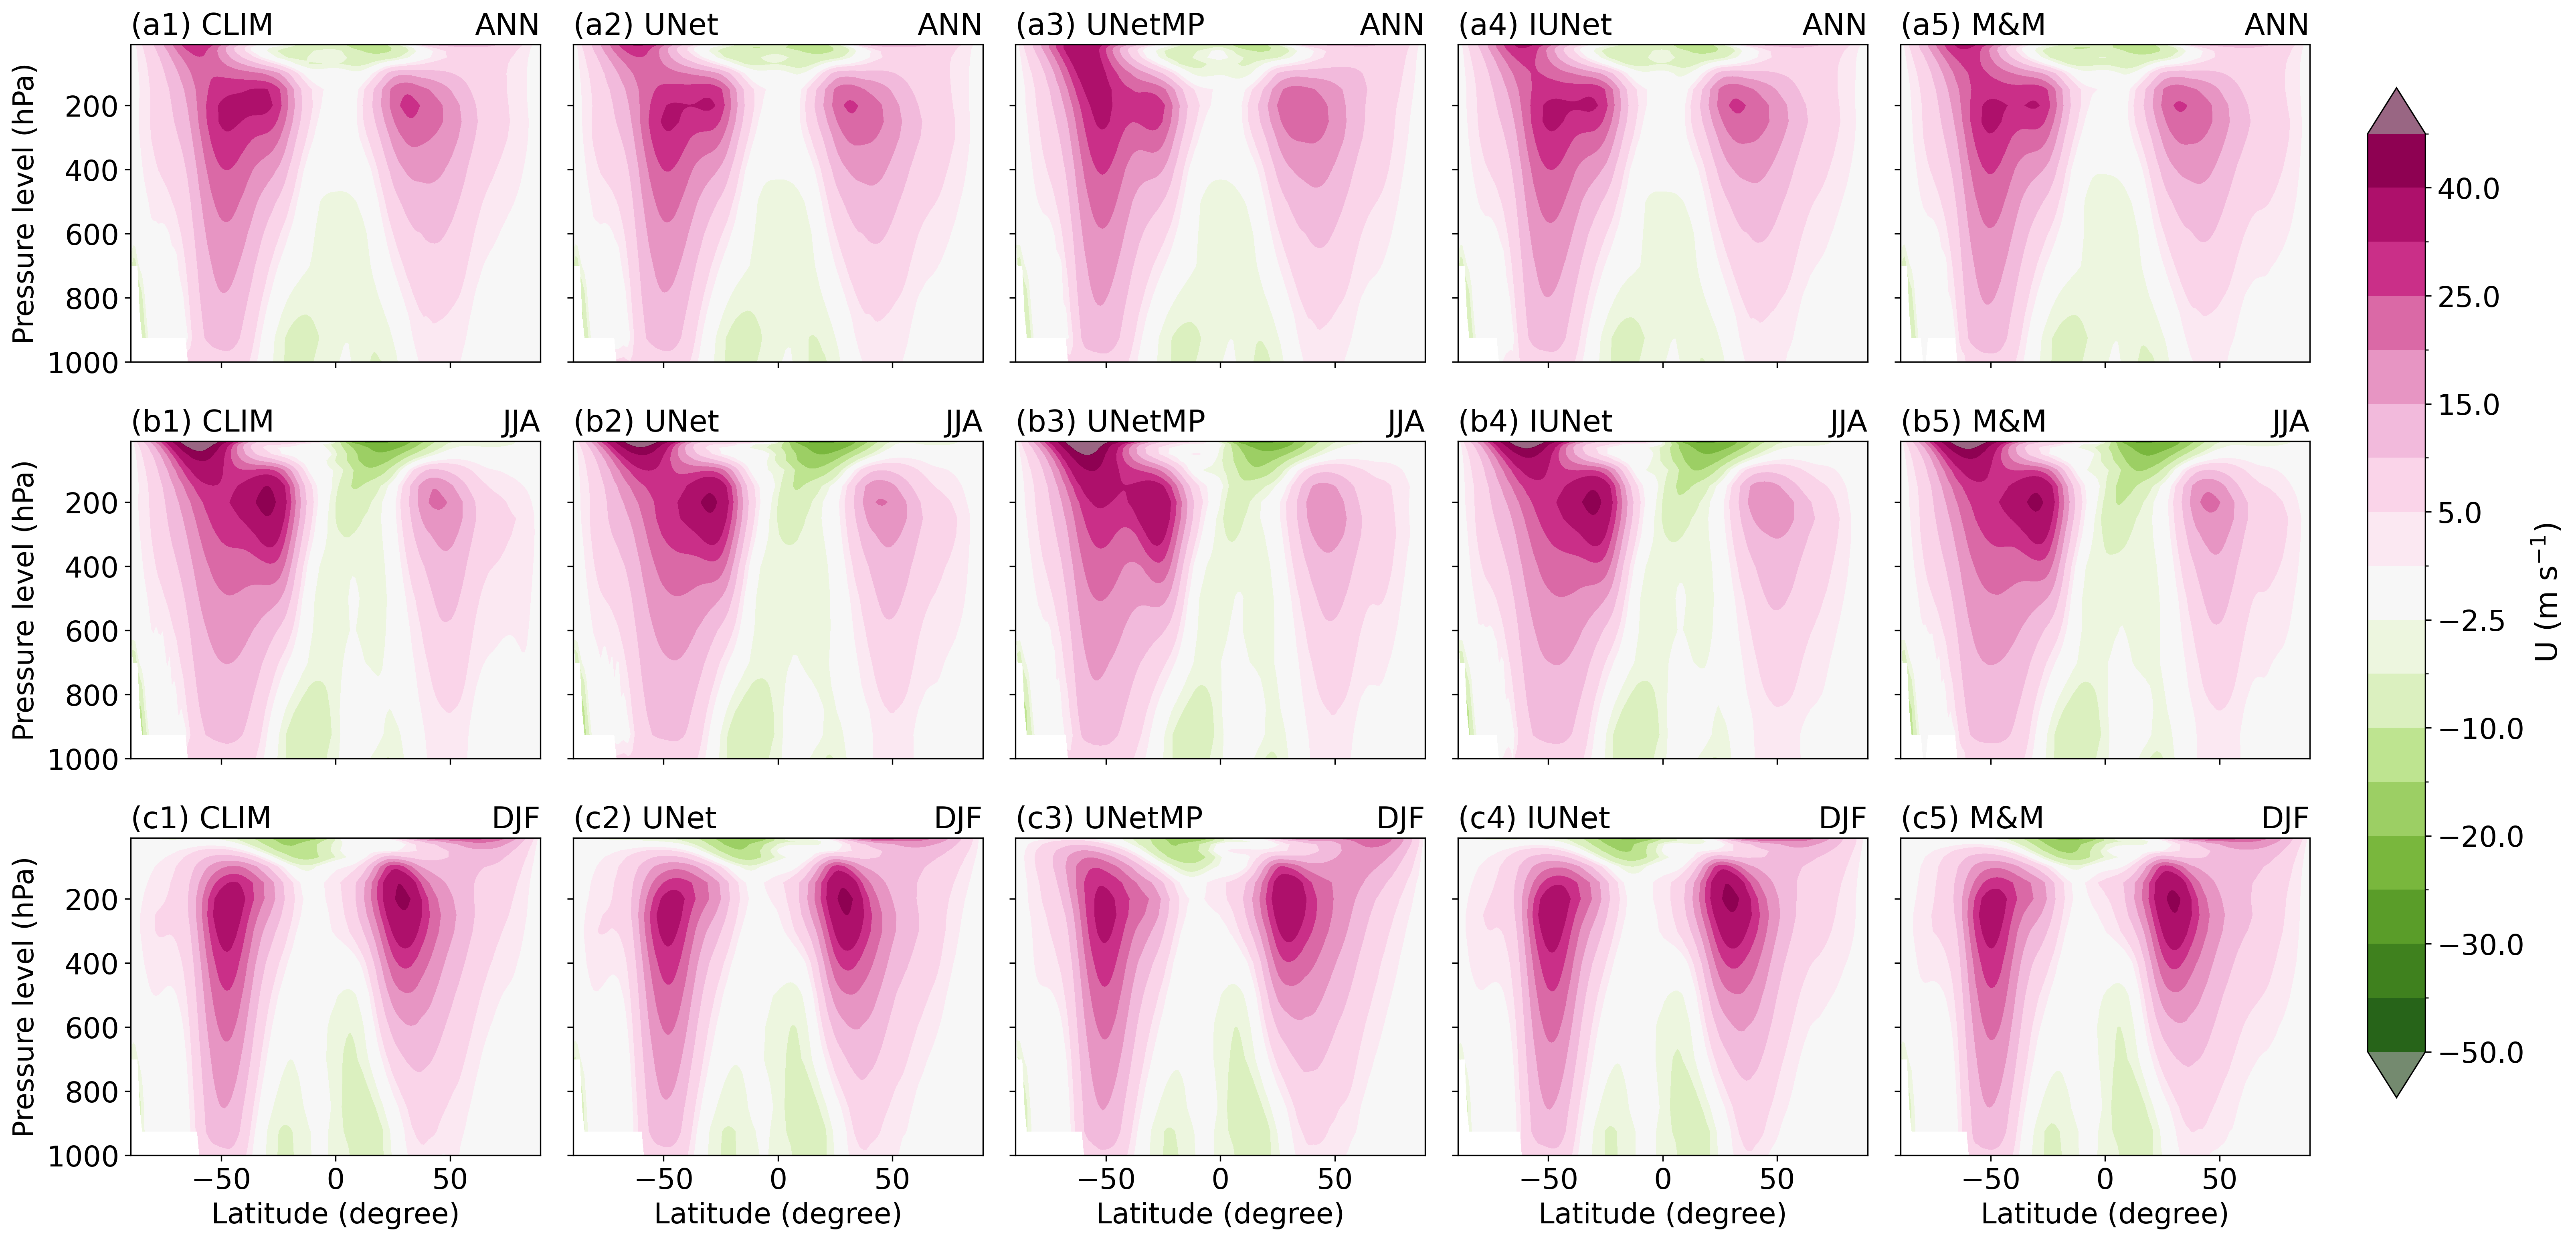

Saved: ./U_global_zonalmean_fcst_ALLMODELS_201201_201612_ANN-SON-DJF.pdf


In [3]:
if __name__ == "__main__":
    # === Define Paths ===
    top_path  = "/pscratch/sd/z/zhan391/SEACROGS_project"
    work_path = f"{top_path}/paper_material/method_paper"
    out_path  = f"{work_path}/fig_data/zonal_mean"      # <-- changed to zonal_mean
    frequency = "monthly"                                # must match calculator.compute() path segment
    out_dir   = os.path.join(out_path, frequency)        # <out_path>/<frequency>
    fig_path  = "./"                                     # where to save PNG/PDF
    os.makedirs(fig_path, exist_ok=True)

    # === Time / seasons ===
    period      = "201201_201612"   # must match ZonalMeanCalculator._period_label()
    seasons_all = ["DJF", "MAM", "JJA", "SON", "ANN"]
    seasons_row = ("ANN", "JJA", "DJF")  # rows to plot

    region = "global"
    var    = "U"                 # e.g., "U","V","T","Z","Q"
    pmin   = 10    # hPa
    pmax   = 1000  # hPa
    metric = "zonalmean"
    data_var = "fcst"
    
    # === Variable display config (for colorbar/levels) ===
    var_dict = {
        'U': {'alias': 'U',  'unit': 'm s$^{-1}$',
              'fscl': 1.0, 'min': -5,  'max': 5,
              'levs': [-50,-40,-30,-25,-20,-15,-10,-5,-2.5,2.5,5,10,15,20,25,30,40,50]
             },
        'V': {'alias': 'V',  'unit': 'm s$^{-1}$',
              'fscl': 1.0, 'min': -1,  'max': 1,
              'levs': [-20,-15,-10,-5,-2,-1,0,1,2,5,10,15,20]
             },
        'T': {'alias': 'T',  'unit': '°C',
              'fscl': 1.0, 'min': -5,  'max': 5,
              'levs': [-60,-55,-50,-40,-30,-20,-10,-5,0,5,10,20,30,40,50,55,60]
             },
        'Q': {'alias': 'Q',  'unit': 'g kg$^{-1}$',
              'fscl': 1.0,  'min': -1,  'max': 1,
              'levs': [0,0.2,0.5,1,2,3,4,6,8,10,12,14,16,18,20]
             },
        'Z': {'alias': 'Z3', 'unit': 'm',
              'fscl': 1.0, 'min': -200,'max': 200,
              'levs': [0,50,100,150,200,300,400,500,600,800,1000,1500,2000]
             },
    }
    
    # === Experiments & variable setup ===
    exp_name_map = {
        "CLIM":   "CLIM",
        "UNet":   "UNet",
        "UNetMP": "UNetMP",
        "IUNet":  "IUNet",
        "MnM":    "M&M",
    }
    
    # Build file paths
    files = [
        os.path.join(out_dir, f"{var}_{region}_{metric}_{exp}_{period}.nc")
        for exp in exp_name_map.keys()
    ]
    
    # Corresponding labels
    labels = [exp_name_map[exp] for exp in exp_name_map.keys()]

    # Pick colorbar limits for the chosen var
    vmin   = var_dict[var]['min']
    vmax   = var_dict[var]['max']
    nlevs  = len(var_dict[var]['levs'])
    levs   = var_dict[var]['levs']

    clim   = None
    dpi    = 300
    figsize = (24, 12)

    # === Style (optional) ===
    fontsize = 18
    plt.rcParams.update({
        "font.size": fontsize,
        "axes.titlesize": fontsize * 0.9,
        "axes.labelsize": fontsize * 0.85,
        "xtick.labelsize": fontsize * 0.8,
        "ytick.labelsize": fontsize * 0.8,
        "legend.fontsize": fontsize * 0.75,
    })

    # (Optional) colormap handle
    index = np.linspace(0.05, 0.95, 20)
    if var in ("Q", "Z"):
        newcmp = "viridis"
    elif var == "T":
        newcmp = "Spectral_r"
    else:
        newcmp = "PiYG_r"   # still diverging for winds
        
    # === Instantiate the new plotter ===
    # Expect files named: {var}_{region}_zonalmean_{EXP}_{period}.nc
    plotter = E3SMZonalPlotter(
        out_dir=out_dir,
        region=region,
        metric=metric,      # <-- updated metric tag
        seasons=seasons_all
    )

    # --- Plot zonal mean (model) fields ---
    fig, axes = plotter.plot_multi_model_zonal_contours(
        files=files,
        labels=labels,
        var=var,
        data_var=data_var,            
        seasons=seasons_row,
        vmin=vmin,
        vmax=vmax,
        pmin=pmin,
        pmax=pmax,
        levels=levs, 
        nlevels=nlevs,
        clim=clim,
        cmap=newcmp,                  # <--- new
        figsize=figsize,
        fontsize=fontsize,
        dpi=dpi
    )
    
    outpdf = os.path.join(fig_path, f"{var}_{region}_{metric}_{data_var}_ALLMODELS_{period}_ANN-SON-DJF.pdf")
    fig.savefig(outpdf, dpi=dpi, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"Saved: {outpdf}")


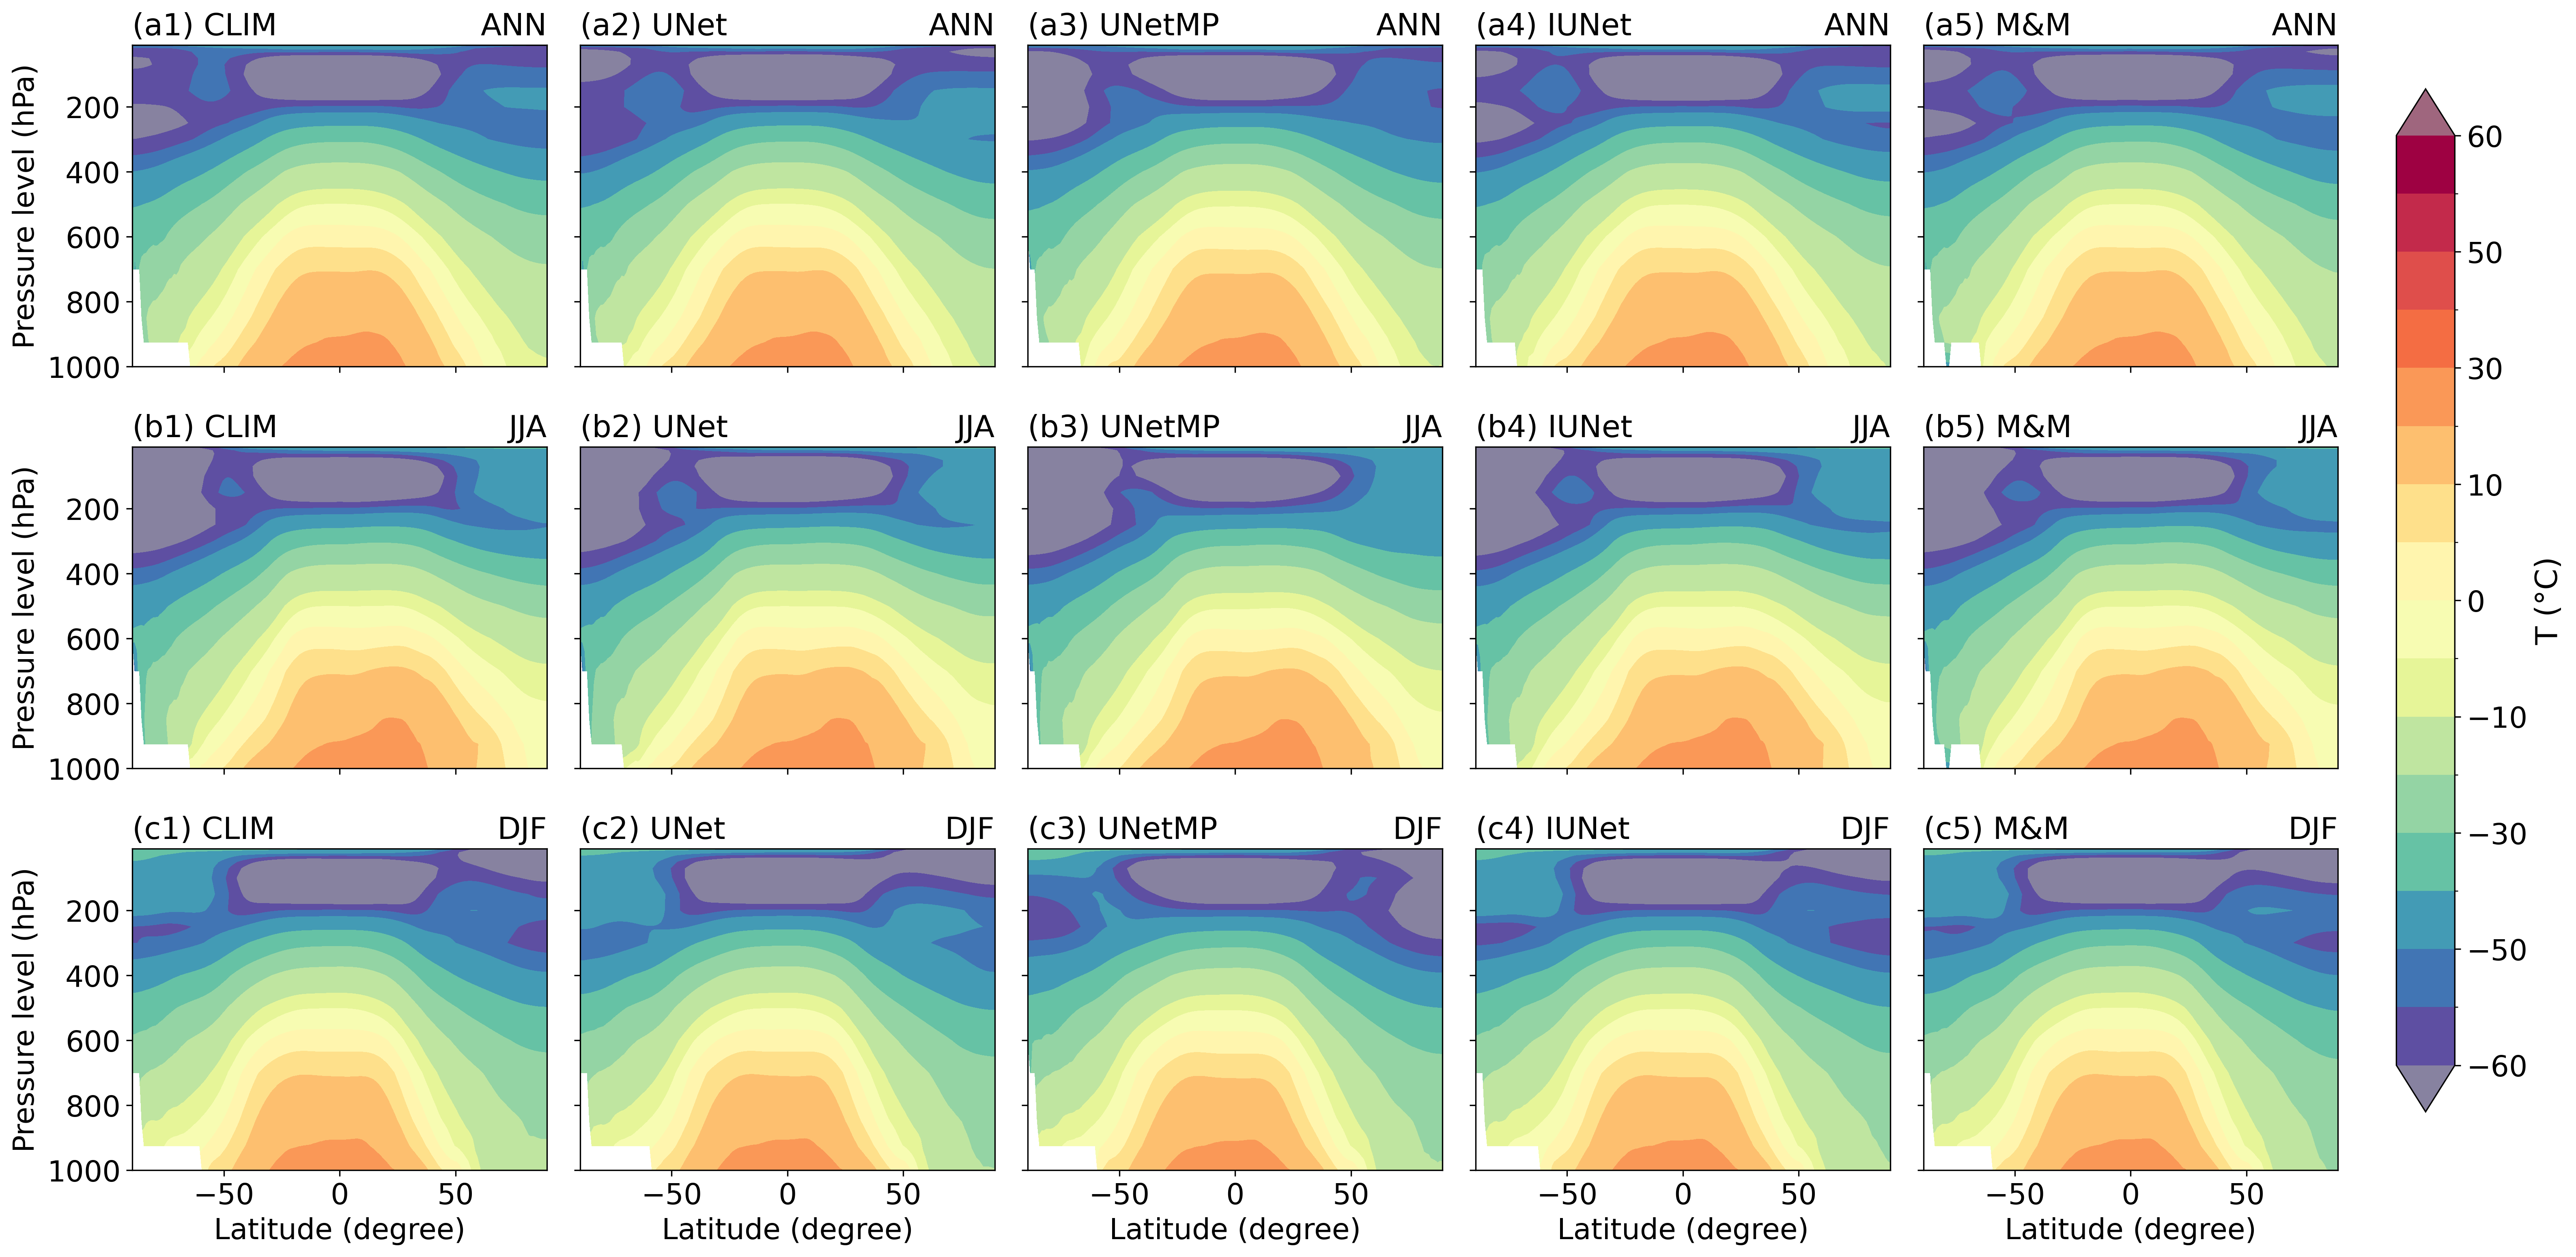

Saved: ./T_global_zonalmean_fcst_ALLMODELS_201201_201612_ANN-SON-DJF.pdf


In [4]:
if __name__ == "__main__":
    # === Define Paths ===
    top_path  = "/pscratch/sd/z/zhan391/SEACROGS_project"
    work_path = f"{top_path}/paper_material/method_paper"
    out_path  = f"{work_path}/fig_data/zonal_mean"      # <-- changed to zonal_mean
    frequency = "monthly"                                # must match calculator.compute() path segment
    out_dir   = os.path.join(out_path, frequency)        # <out_path>/<frequency>
    fig_path  = "./"                                     # where to save PNG/PDF
    os.makedirs(fig_path, exist_ok=True)

    # === Time / seasons ===
    period      = "201201_201612"   # must match ZonalMeanCalculator._period_label()
    seasons_all = ["DJF", "MAM", "JJA", "SON", "ANN"]
    seasons_row = ("ANN", "JJA", "DJF")  # rows to plot

    region = "global"
    var    = "T"                 # e.g., "U","V","T","Z","Q"
    pmin   = 10    # hPa
    pmax   = 1000  # hPa
    metric = "zonalmean"
    data_var = "fcst"
    
    # === Variable display config (for colorbar/levels) ===
    var_dict = {
        'U': {'alias': 'U',  'unit': 'm s$^{-1}$',
              'fscl': 1.0, 'min': -5,  'max': 5,
              'levs': [-50,-40,-30,-25,-20,-15,-10,-5,-2.5,2.5,5,10,15,20,25,30,40,50]
             },
        'V': {'alias': 'V',  'unit': 'm s$^{-1}$',
              'fscl': 1.0, 'min': -1,  'max': 1,
              'levs': [-20,-15,-10,-5,-2,-1,0,1,2,5,10,15,20]
             },
        'T': {'alias': 'T',  'unit': '°C',
              'fscl': 1.0, 'min': -5,  'max': 5,
              'levs': [-60,-55,-50,-40,-30,-20,-10,-5,0,5,10,20,30,40,50,55,60]
             },
        'Q': {'alias': 'Q',  'unit': 'g kg$^{-1}$',
              'fscl': 1.0,  'min': -1,  'max': 1,
              'levs': [0,0.2,0.5,1,2,3,4,6,8,10,12,14,16,18,20]
             },
        'Z': {'alias': 'Z3', 'unit': 'm',
              'fscl': 1.0, 'min': -200,'max': 200,
              'levs': [0,50,100,150,200,300,400,500,600,800,1000,1500,2000]
             },
    }
    
    # === Experiments & variable setup ===
    exp_name_map = {
        "CLIM":   "CLIM",
        "UNet":   "UNet",
        "UNetMP": "UNetMP",
        "IUNet":  "IUNet",
        "MnM":    "M&M",
    }
    
    # Build file paths
    files = [
        os.path.join(out_dir, f"{var}_{region}_{metric}_{exp}_{period}.nc")
        for exp in exp_name_map.keys()
    ]
    
    # Corresponding labels
    labels = [exp_name_map[exp] for exp in exp_name_map.keys()]

    # Pick colorbar limits for the chosen var
    vmin   = var_dict[var]['min']
    vmax   = var_dict[var]['max']
    nlevs  = len(var_dict[var]['levs'])
    levs   = var_dict[var]['levs']

    clim   = None
    dpi    = 300
    figsize = (24, 12)

    # === Style (optional) ===
    fontsize = 18
    plt.rcParams.update({
        "font.size": fontsize,
        "axes.titlesize": fontsize * 0.9,
        "axes.labelsize": fontsize * 0.85,
        "xtick.labelsize": fontsize * 0.8,
        "ytick.labelsize": fontsize * 0.8,
        "legend.fontsize": fontsize * 0.75,
    })

    # (Optional) colormap handle
    index = np.linspace(0.05, 0.95, 20)
    if var in ("Q", "Z"):
        newcmp = "viridis"
    elif var == "T":
        newcmp = "Spectral_r"
    else:
        newcmp = "PiYG_r"   # still diverging for winds
        
    # === Instantiate the new plotter ===
    # Expect files named: {var}_{region}_zonalmean_{EXP}_{period}.nc
    plotter = E3SMZonalPlotter(
        out_dir=out_dir,
        region=region,
        metric=metric,      # <-- updated metric tag
        seasons=seasons_all
    )

    # --- Plot zonal mean (model) fields ---
    fig, axes = plotter.plot_multi_model_zonal_contours(
        files=files,
        labels=labels,
        var=var,
        data_var=data_var,            
        seasons=seasons_row,
        vmin=vmin,
        vmax=vmax,
        pmin=pmin,
        pmax=pmax,
        levels=levs, 
        nlevels=nlevs,
        clim=clim,
        cmap=newcmp,                  # <--- new
        figsize=figsize,
        fontsize=fontsize,
        dpi=dpi
    )
    
    outpdf = os.path.join(fig_path, f"{var}_{region}_{metric}_{data_var}_ALLMODELS_{period}_ANN-SON-DJF.pdf")
    fig.savefig(outpdf, dpi=dpi, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"Saved: {outpdf}")
